# Compare different preprocessing strategies

In [1]:
%run -i preambles
%run -i helper_functions
%run -i fitting_functions
# # Global parameters:
number_of_cycles = 1 # how many passes through the training data we go through
number_of_groups = 1 # divide the data set into smaller ones, to make fitting easier.
steps_per_batch = 1
dims = 2  # 2D spatial
head = 0 # how many locations to consider in the real data set.

In [2]:
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1", 
    "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr", 
    "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr", "Lhb", "Cga"]

gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1", 
    "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr", 
    "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr"]

puck_list = ['Puck_230517_39'] # the largest puck
adata, X,Y,df=load_data(gene_list=gene_list, head=head, puck_list = puck_list)
df

,x,y,Inha,Inhba,Inhbb,Fst,Esr1,Esr2,Pgr,Ar,...,Parm1,Akr1c18,Fshr,Star,Ptgfr,Sfrp4,Acvr1,Acvr2a,Acvr2b,Ghr
CTACACATTAAAGG-1-2,1.7582,2.1860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
AGATGNAGTGGGTG-1-2,1.7295,1.9433,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCCGCAATCCTGAC-1-2,4.2735,2.8661,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CATCCAGACAGCCA-1-2,1.9647,3.2265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
GANTAATGAAANTA-1-2,3.8264,2.0924,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTCATAGGGTATCA-1-2,1.4905,3.0258,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CCGCAGATAACGTA-1-2,3.4387,3.7596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CGTGTNGAGGATAT-1-2,2.7018,1.4625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GTGGTGAACATAGT-1-2,2.2159,3.0753,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,4.0,1.0,5.0,0.0,0.0,0.0,0.0


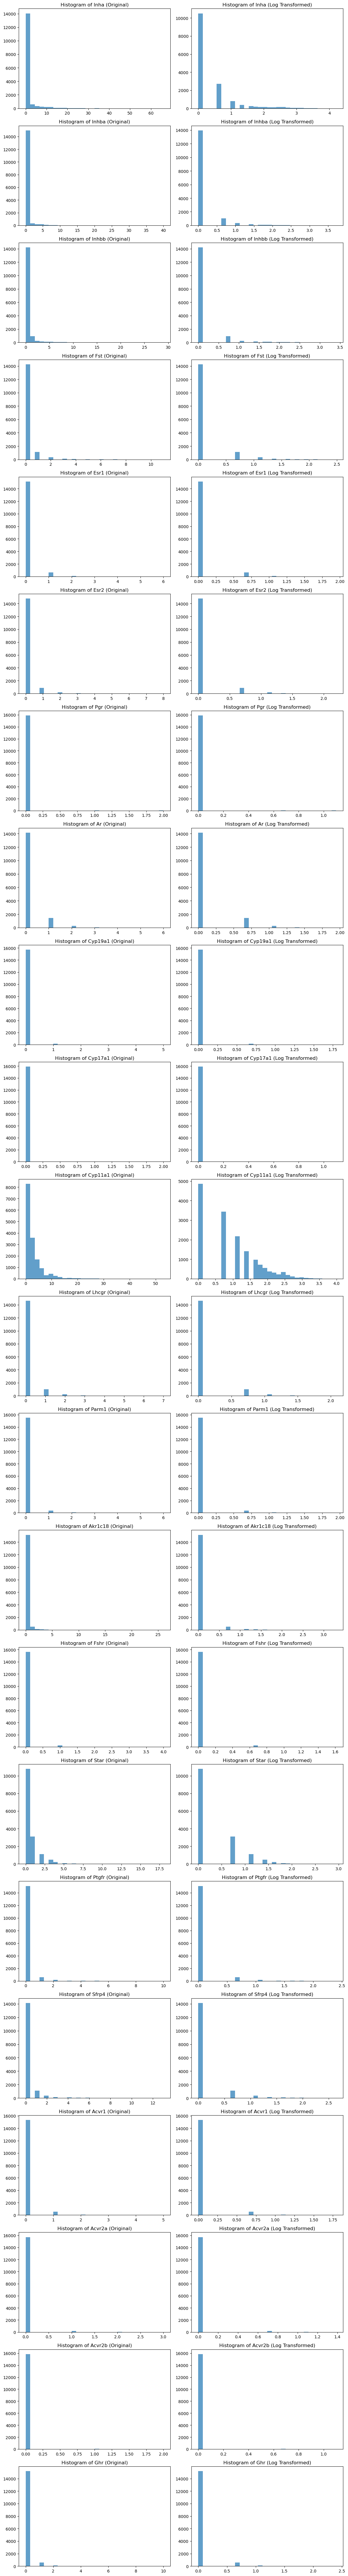

Inha_log: Shapiro-Wilk Test: Stat=0.6480399209807246, p-value=5.3895080589046366e-101
Inhba_log: Shapiro-Wilk Test: Stat=0.37852523572380925, p-value=8.648838305199432e-116
Inhbb_log: Shapiro-Wilk Test: Stat=0.3465322680440278, p-value=3.814131510355456e-117
Fst_log: Shapiro-Wilk Test: Stat=0.3600672675640366, p-value=1.4046694773567577e-116
Esr1_log: Shapiro-Wilk Test: Stat=0.22083880573342685, p-value=5.853079785023968e-122
Esr2_log: Shapiro-Wilk Test: Stat=0.2829466378169778, p-value=1.1290660067935258e-119
Pgr_log: Shapiro-Wilk Test: Stat=0.017628879692422883, p-value=1.8856482007549574e-128
Ar_log: Shapiro-Wilk Test: Stat=0.3741836193148206, p-value=5.616167213746866e-116
Cyp19a1_log: Shapiro-Wilk Test: Stat=0.08447866620181432, p-value=1.8523907179705847e-126
Cyp17a1_log: Shapiro-Wilk Test: Stat=0.013168734311496566, p-value=1.4023751741776313e-128
Cyp11a1_log: Shapiro-Wilk Test: Stat=0.9077788307970922, p-value=3.30494609034572e-70
Lhcgr_log: Shapiro-Wilk Test: Stat=0.3078071060

/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15907.
  res = hypotest_fun_out(*samples, **kwds)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Log transformation
for gene in gene_list:
    df[gene + '_log'] = np.log(df[gene] + 1)

# Plot before and after log transformation for all genes
fig, axes = plt.subplots(nrows=len(gene_list), ncols=2, figsize=(12, len(gene_list) * 4))

for i, gene in enumerate(gene_list):
    axes[i, 0].hist(df[gene], bins=30, alpha=0.7)
    axes[i, 0].set_title(f"Histogram of {gene} (Original)")
    
    axes[i, 1].hist(df[gene + '_log'], bins=30, alpha=0.7)
    axes[i, 1].set_title(f"Histogram of {gene} (Log Transformed)")

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality
for gene in gene_list:
    stat, p = stats.shapiro(df[gene + '_log'])
    print(f'{gene}_log: Shapiro-Wilk Test: Stat={stat}, p-value={p}')

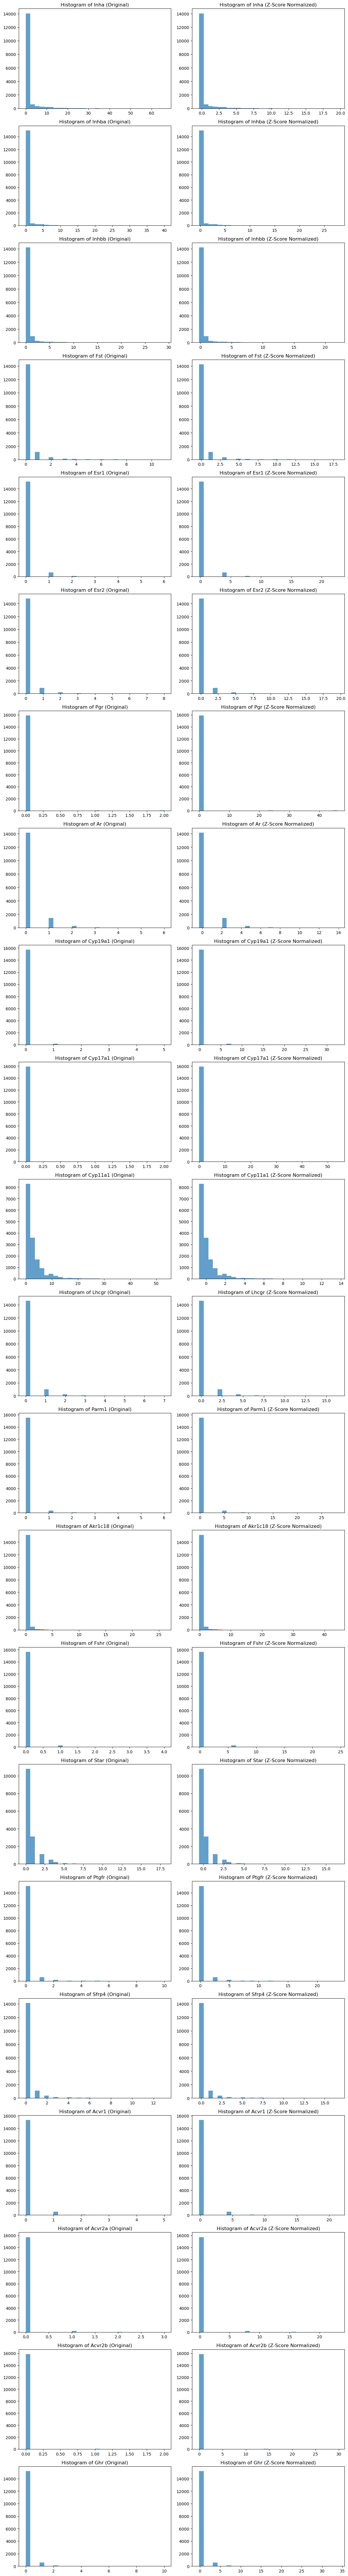

Inha_zscore: Shapiro-Wilk Test: Stat=0.4177239499923737, p-value=4.8345865641282954e-114
Inhba_zscore: Shapiro-Wilk Test: Stat=0.2429844528651276, p-value=3.6572021019543785e-121
Inhbb_zscore: Shapiro-Wilk Test: Stat=0.24079384336394405, p-value=3.0445424175813108e-121
Fst_zscore: Shapiro-Wilk Test: Stat=0.3062157201703918, p-value=8.999513743014552e-119
Esr1_zscore: Shapiro-Wilk Test: Stat=0.20982392430761543, p-value=2.3933754392536384e-122
Esr2_zscore: Shapiro-Wilk Test: Stat=0.2524556834042304, p-value=8.124254921113904e-121
Pgr_zscore: Shapiro-Wilk Test: Stat=0.017409234441310373, p-value=1.8582992800518386e-128
Ar_zscore: Shapiro-Wilk Test: Stat=0.352673539881857, p-value=6.870593551730397e-117
Cyp19a1_zscore: Shapiro-Wilk Test: Stat=0.07635642844174217, p-value=1.044504432486006e-126
Cyp17a1_zscore: Shapiro-Wilk Test: Stat=0.012934875718661809, p-value=1.3808158774178155e-128
Cyp11a1_zscore: Shapiro-Wilk Test: Stat=0.6987182433576847, p-value=3.962675444722504e-97
Lhcgr_zscore: 

/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15907.
  res = hypotest_fun_out(*samples, **kwds)


In [4]:
# Z-score normalization
for gene in gene_list:
    df[gene + '_zscore'] = (df[gene] - df[gene].mean()) / df[gene].std()

# Plot before and after z-score normalization for all genes
fig, axes = plt.subplots(nrows=len(gene_list), ncols=2, figsize=(12, len(gene_list) * 4))

for i, gene in enumerate(gene_list):
    axes[i, 0].hist(df[gene], bins=30, alpha=0.7)
    axes[i, 0].set_title(f"Histogram of {gene} (Original)")
    
    axes[i, 1].hist(df[gene + '_zscore'], bins=30, alpha=0.7)
    axes[i, 1].set_title(f"Histogram of {gene} (Z-Score Normalized)")

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality
for gene in gene_list:
    stat, p = stats.shapiro(df[gene + '_zscore'])
    print(f'{gene}_zscore: Shapiro-Wilk Test: Stat={stat}, p-value={p}')

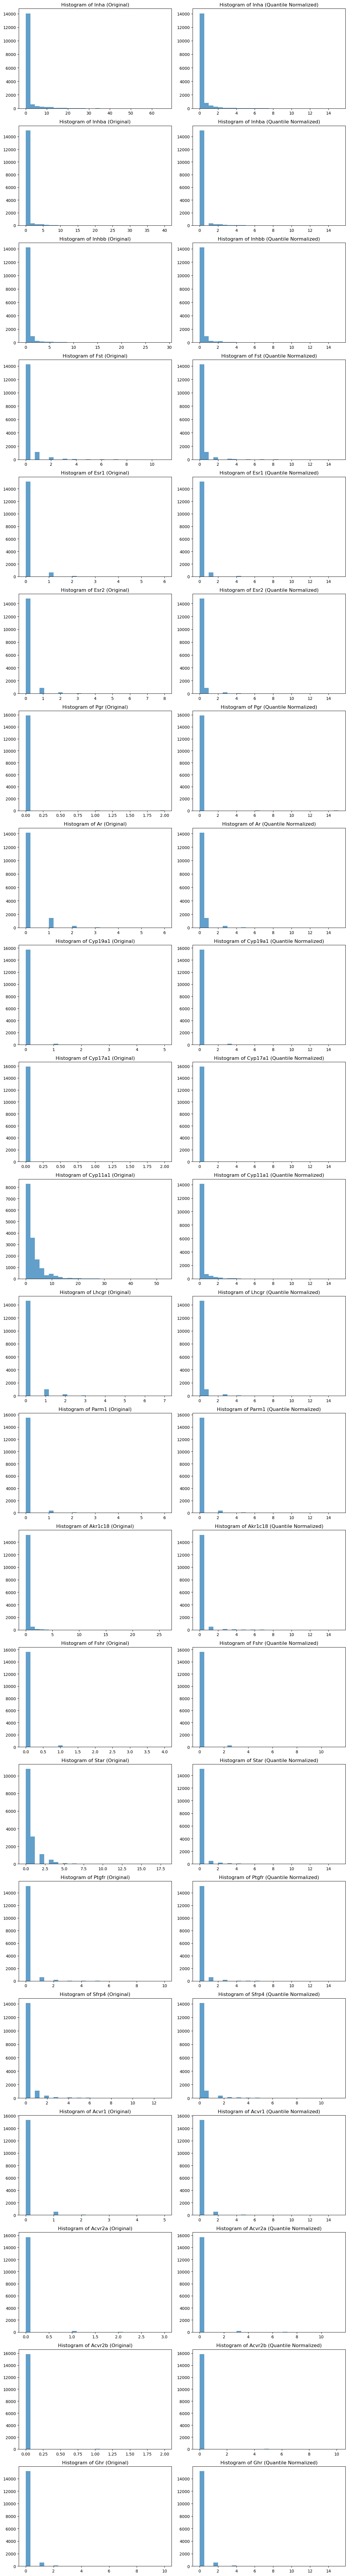

Inha_quantile_normalized: Shapiro-Wilk Test: Stat=0.3823097896741492, p-value=1.2628750044387172e-115
Inhba_quantile_normalized: Shapiro-Wilk Test: Stat=0.2777055656358982, p-value=7.132477123168255e-120
Inhbb_quantile_normalized: Shapiro-Wilk Test: Stat=0.28141621381921, p-value=9.870461313060613e-120
Fst_quantile_normalized: Shapiro-Wilk Test: Stat=0.2688426673162614, p-value=3.302212487126208e-120
Esr1_quantile_normalized: Shapiro-Wilk Test: Stat=0.17714870326709908, p-value=1.796675737294006e-123
Esr2_quantile_normalized: Shapiro-Wilk Test: Stat=0.21339283173071122, p-value=3.193885306447102e-122
Pgr_quantile_normalized: Shapiro-Wilk Test: Stat=0.017045390337217192, p-value=1.8138771318365895e-128
Ar_quantile_normalized: Shapiro-Wilk Test: Stat=0.2427945106592676, p-value=3.599454154658705e-121
Cyp19a1_quantile_normalized: Shapiro-Wilk Test: Stat=0.07944732368814711, p-value=1.298282788389587e-126
Cyp17a1_quantile_normalized: Shapiro-Wilk Test: Stat=0.012783911601322528, p-value=1.

/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15907.
  res = hypotest_fun_out(*samples, **kwds)


In [5]:
def quantile_normalize(df_input):
    sorted_df = np.sort(df_input.values, axis=0)
    rank_mean = sorted_df.mean(axis=1)
    df_output = df_input.rank(method="min").stack().astype(int).map(dict(zip(range(1, len(rank_mean)+1), rank_mean))).unstack()
    return df_output

# Apply quantile normalization
df_quantile_normalized = quantile_normalize(df[gene_list])

# Plot before and after quantile normalization for all genes
fig, axes = plt.subplots(nrows=len(gene_list), ncols=2, figsize=(12, len(gene_list) * 4))

for i, gene in enumerate(gene_list):
    axes[i, 0].hist(df[gene], bins=30, alpha=0.7)
    axes[i, 0].set_title(f"Histogram of {gene} (Original)")
    
    axes[i, 1].hist(df_quantile_normalized[gene], bins=30, alpha=0.7)
    axes[i, 1].set_title(f"Histogram of {gene} (Quantile Normalized)")

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality
for gene in gene_list:
    stat, p = stats.shapiro(df_quantile_normalized[gene])
    print(f'{gene}_quantile_normalized: Shapiro-Wilk Test: Stat={stat}, p-value={p}')

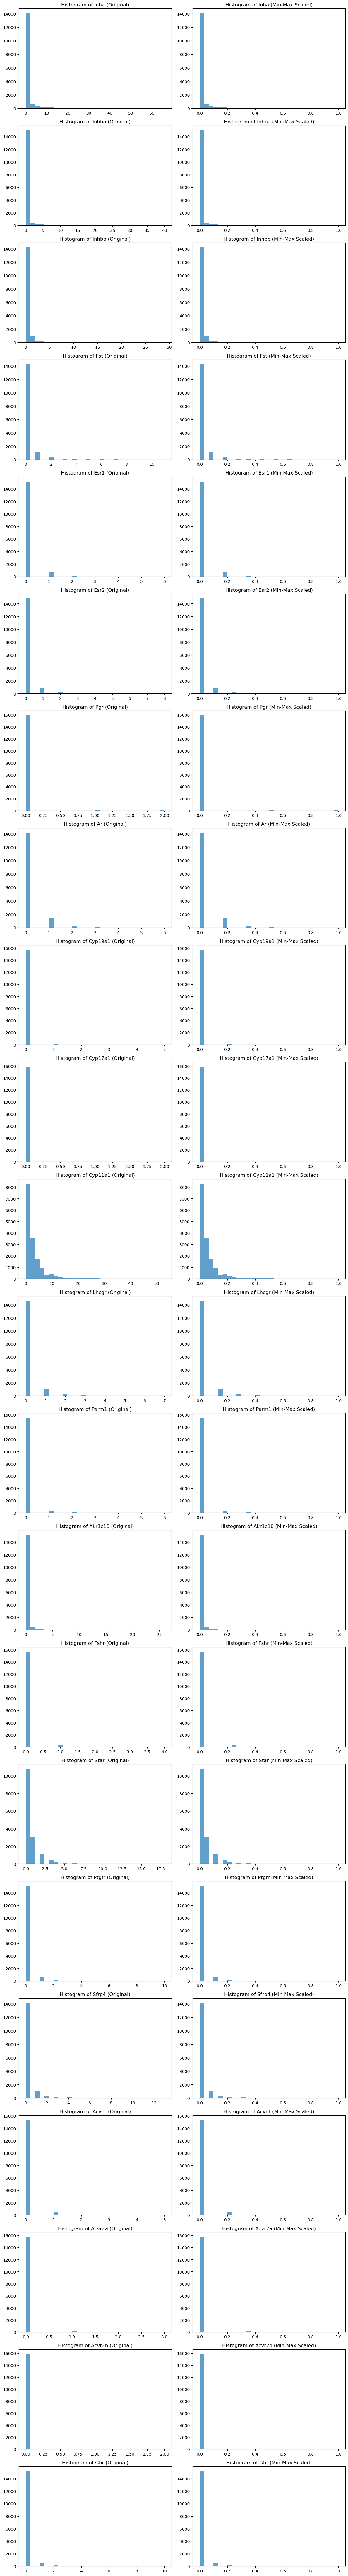

Inha_minmax_scaled: Shapiro-Wilk Test: Stat=0.4177239517286816, p-value=4.834587451010404e-114
Inhba_minmax_scaled: Shapiro-Wilk Test: Stat=0.24298445379064249, p-value=3.6572023856143217e-121
Inhbb_minmax_scaled: Shapiro-Wilk Test: Stat=0.24079384196339537, p-value=3.0445420611499147e-121
Fst_minmax_scaled: Shapiro-Wilk Test: Stat=0.30621572444834144, p-value=8.999517228035063e-119
Esr1_minmax_scaled: Shapiro-Wilk Test: Stat=0.20982392364220148, p-value=2.3933753107562282e-122
Esr2_minmax_scaled: Shapiro-Wilk Test: Stat=0.2524556793463619, p-value=8.124252127390092e-121
Pgr_minmax_scaled: Shapiro-Wilk Test: Stat=0.01740923447100895, p-value=1.8582992837224058e-128
Ar_minmax_scaled: Shapiro-Wilk Test: Stat=0.3526735452850077, p-value=6.87059712419778e-117
Cyp19a1_minmax_scaled: Shapiro-Wilk Test: Stat=0.07635642773583518, p-value=1.044504380679171e-126
Cyp17a1_minmax_scaled: Shapiro-Wilk Test: Stat=0.012934875776323795, p-value=1.3808158826919823e-128
Cyp11a1_minmax_scaled: Shapiro-Wil

/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15907.
  res = hypotest_fun_out(*samples, **kwds)


In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax_scaled = df.copy()

# Apply min-max scaling
df_minmax_scaled[gene_list] = scaler.fit_transform(df[gene_list])

# Plot before and after min-max scaling for all genes
fig, axes = plt.subplots(nrows=len(gene_list), ncols=2, figsize=(12, len(gene_list) * 4))

for i, gene in enumerate(gene_list):
    axes[i, 0].hist(df[gene], bins=30, alpha=0.7)
    axes[i, 0].set_title(f"Histogram of {gene} (Original)")
    
    axes[i, 1].hist(df_minmax_scaled[gene], bins=30, alpha=0.7)
    axes[i, 1].set_title(f"Histogram of {gene} (Min-Max Scaled)")

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality
for gene in gene_list:
    stat, p = stats.shapiro(df_minmax_scaled[gene])
    print(f'{gene}_minmax_scaled: Shapiro-Wilk Test: Stat={stat}, p-value={p}')

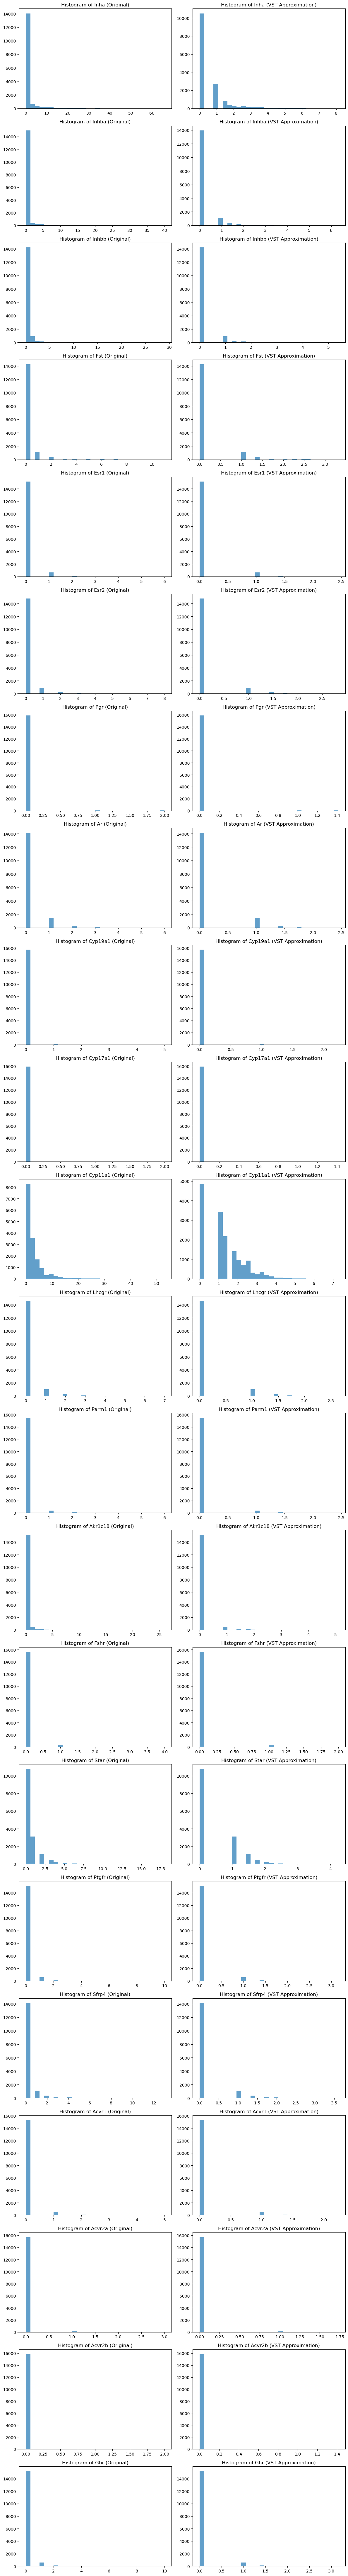

Inha_sqrt: Shapiro-Wilk Test: Stat=0.6464003174215776, p-value=4.118912766896848e-101
Inhba_sqrt: Shapiro-Wilk Test: Stat=0.38248667732921005, p-value=1.285482436965938e-115
Inhbb_sqrt: Shapiro-Wilk Test: Stat=0.35230904943719443, p-value=6.633834386597493e-117
Fst_sqrt: Shapiro-Wilk Test: Stat=0.3656177435478677, p-value=2.4144266525983413e-116
Esr1_sqrt: Shapiro-Wilk Test: Stat=0.22193482811925658, p-value=6.401686781309057e-122
Esr2_sqrt: Shapiro-Wilk Test: Stat=0.28660337008178904, p-value=1.558338444753247e-119
Pgr_sqrt: Shapiro-Wilk Test: Stat=0.017666535233292868, p-value=1.8903776489015814e-128
Ar_sqrt: Shapiro-Wilk Test: Stat=0.3756641383225304, p-value=6.505123014448514e-116
Cyp19a1_sqrt: Shapiro-Wilk Test: Stat=0.08574928551800765, p-value=2.0269107373126655e-126
Cyp17a1_sqrt: Shapiro-Wilk Test: Stat=0.013214109749542069, p-value=1.4065976728925196e-128
Cyp11a1_sqrt: Shapiro-Wilk Test: Stat=0.9044425295353683, p-value=5.968465042058957e-71
Lhcgr_sqrt: Shapiro-Wilk Test: Stat

/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15907.
  res = hypotest_fun_out(*samples, **kwds)


In [7]:
# Apply square root transformation as a proxy for VST
for gene in gene_list:
    df[gene + '_sqrt'] = np.sqrt(df[gene])

# Plot before and after square root transformation for all genes
fig, axes = plt.subplots(nrows=len(gene_list), ncols=2, figsize=(12, len(gene_list) * 4))

for i, gene in enumerate(gene_list):
    axes[i, 0].hist(df[gene], bins=30, alpha=0.7)
    axes[i, 0].set_title(f"Histogram of {gene} (Original)")
    
    axes[i, 1].hist(df[gene + '_sqrt'], bins=30, alpha=0.7)
    axes[i, 1].set_title(f"Histogram of {gene} (VST Approximation)")

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality
for gene in gene_list:
    stat, p = stats.shapiro(df[gene + '_sqrt'])
    print(f'{gene}_sqrt: Shapiro-Wilk Test: Stat={stat}, p-value={p}')